# **Single-Cell RNA-Seq Analysis Project**

In this project, you will work with the `norman` dataset from the `perturbation_data_analysis` exercise:

In [23]:
import os
import sys
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Append the root of the Git repository to the path.
git_root = os.popen(cmd="git rev-parse --show-toplevel").read().strip()
sys.path.append(git_root)

from src.exercises.perturbation_data_analysis import pertdata as pt  # noqa: E402

norman = pt.PertData.from_repo(name="norman", save_dir="data")
adata = norman.adata
print(norman)
print(adata)

Dataset directory already exists: data\norman
Loading dataset: norman
PertData object
    name: norman
    path: data\norman
    adata: AnnData object with n_obs x n_vars = 91205 x 5045
AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'condition_fixed'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'


### 1. Highly Variable Genes
Identify and visualize genes with high variability across cells, as these are often the most informative for clustering.

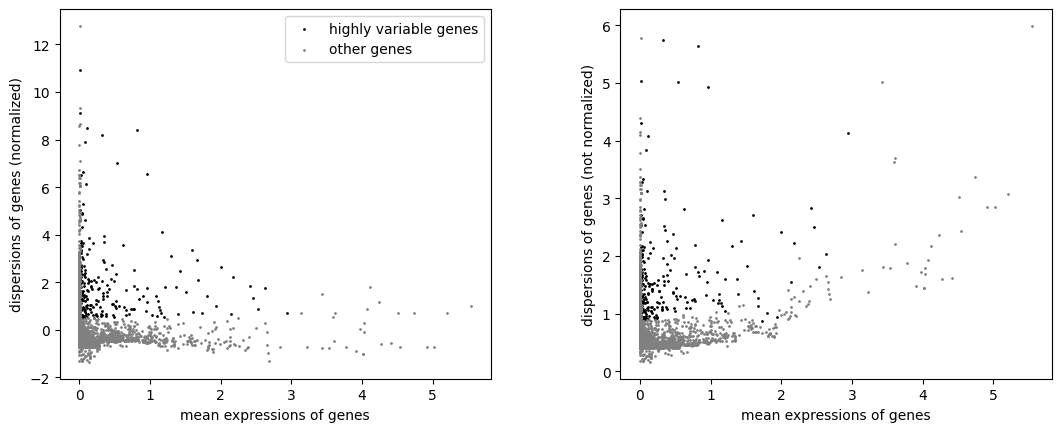

In [24]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

### 2. Dimensionality Reduction & Clustering
Perform PCA for initial dimensionality reduction, compute the neighborhood graph, and then run Leiden clustering and t-SNE/UMAP for visualization.

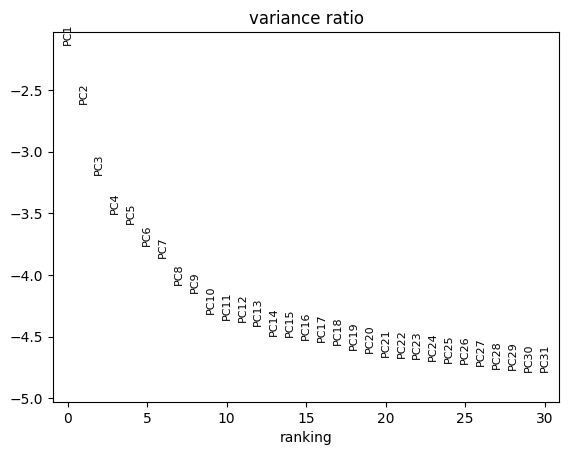

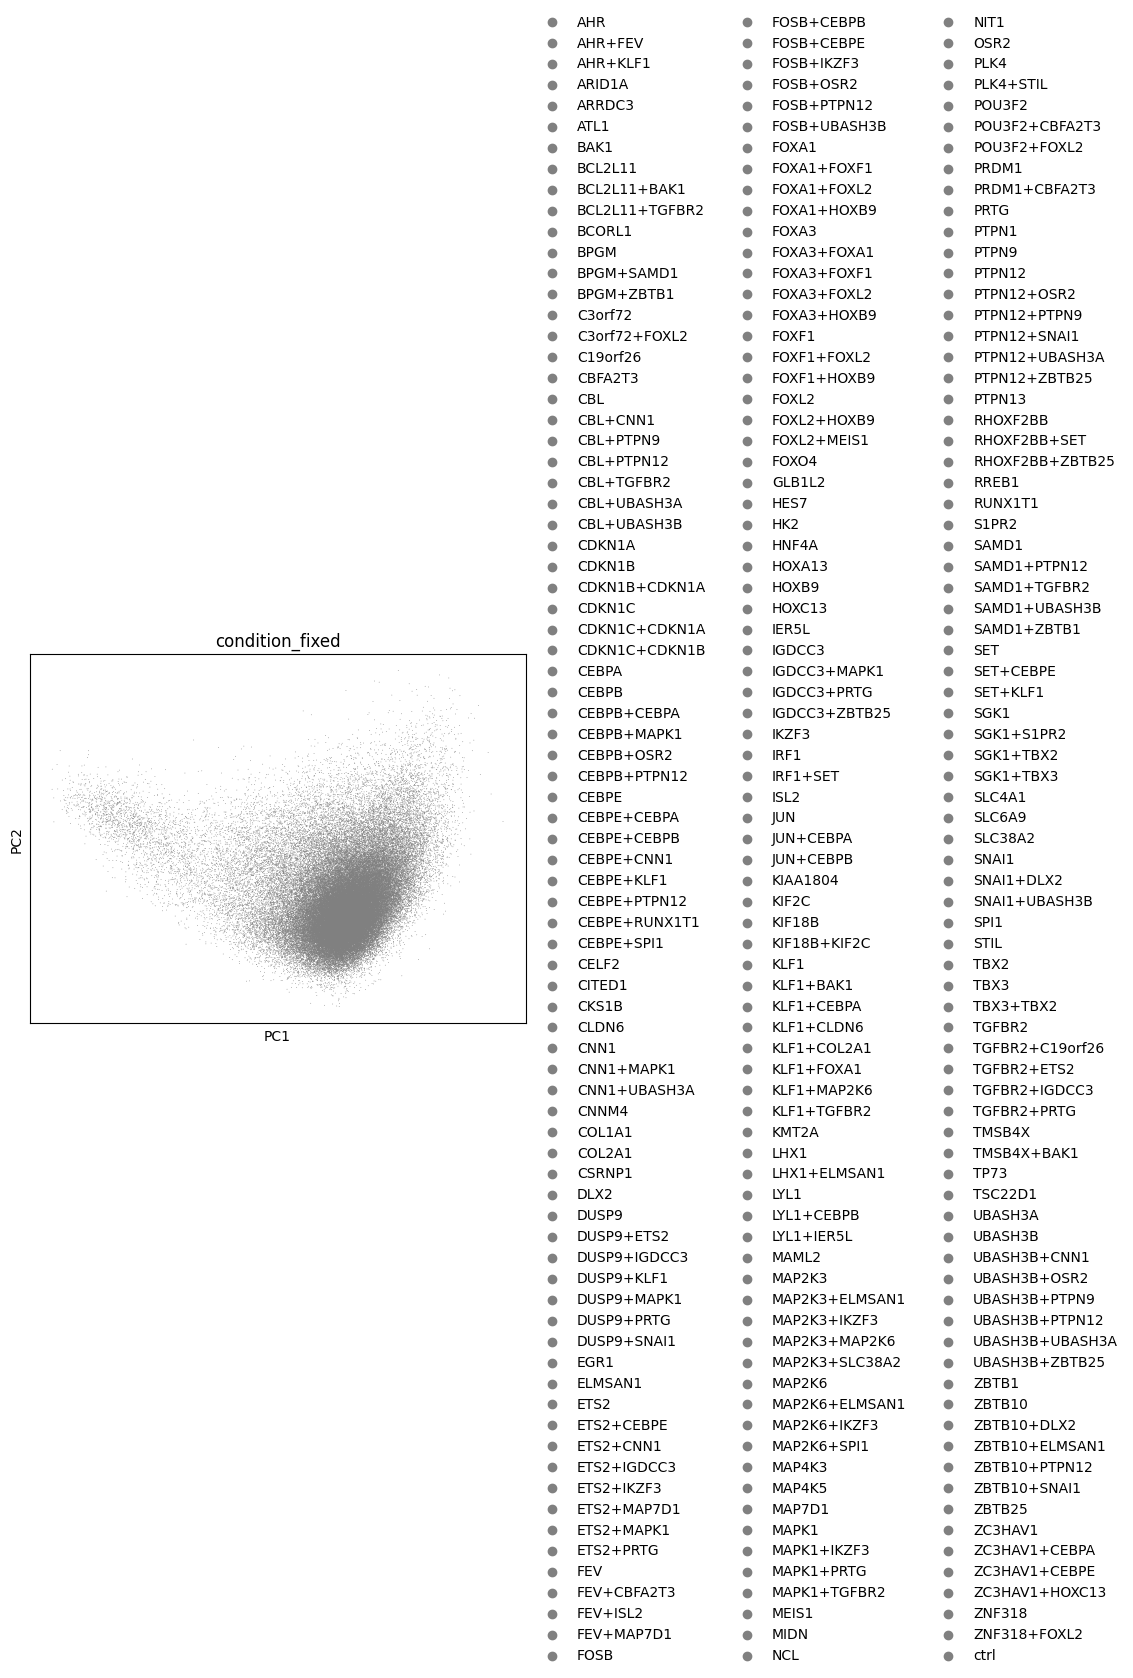

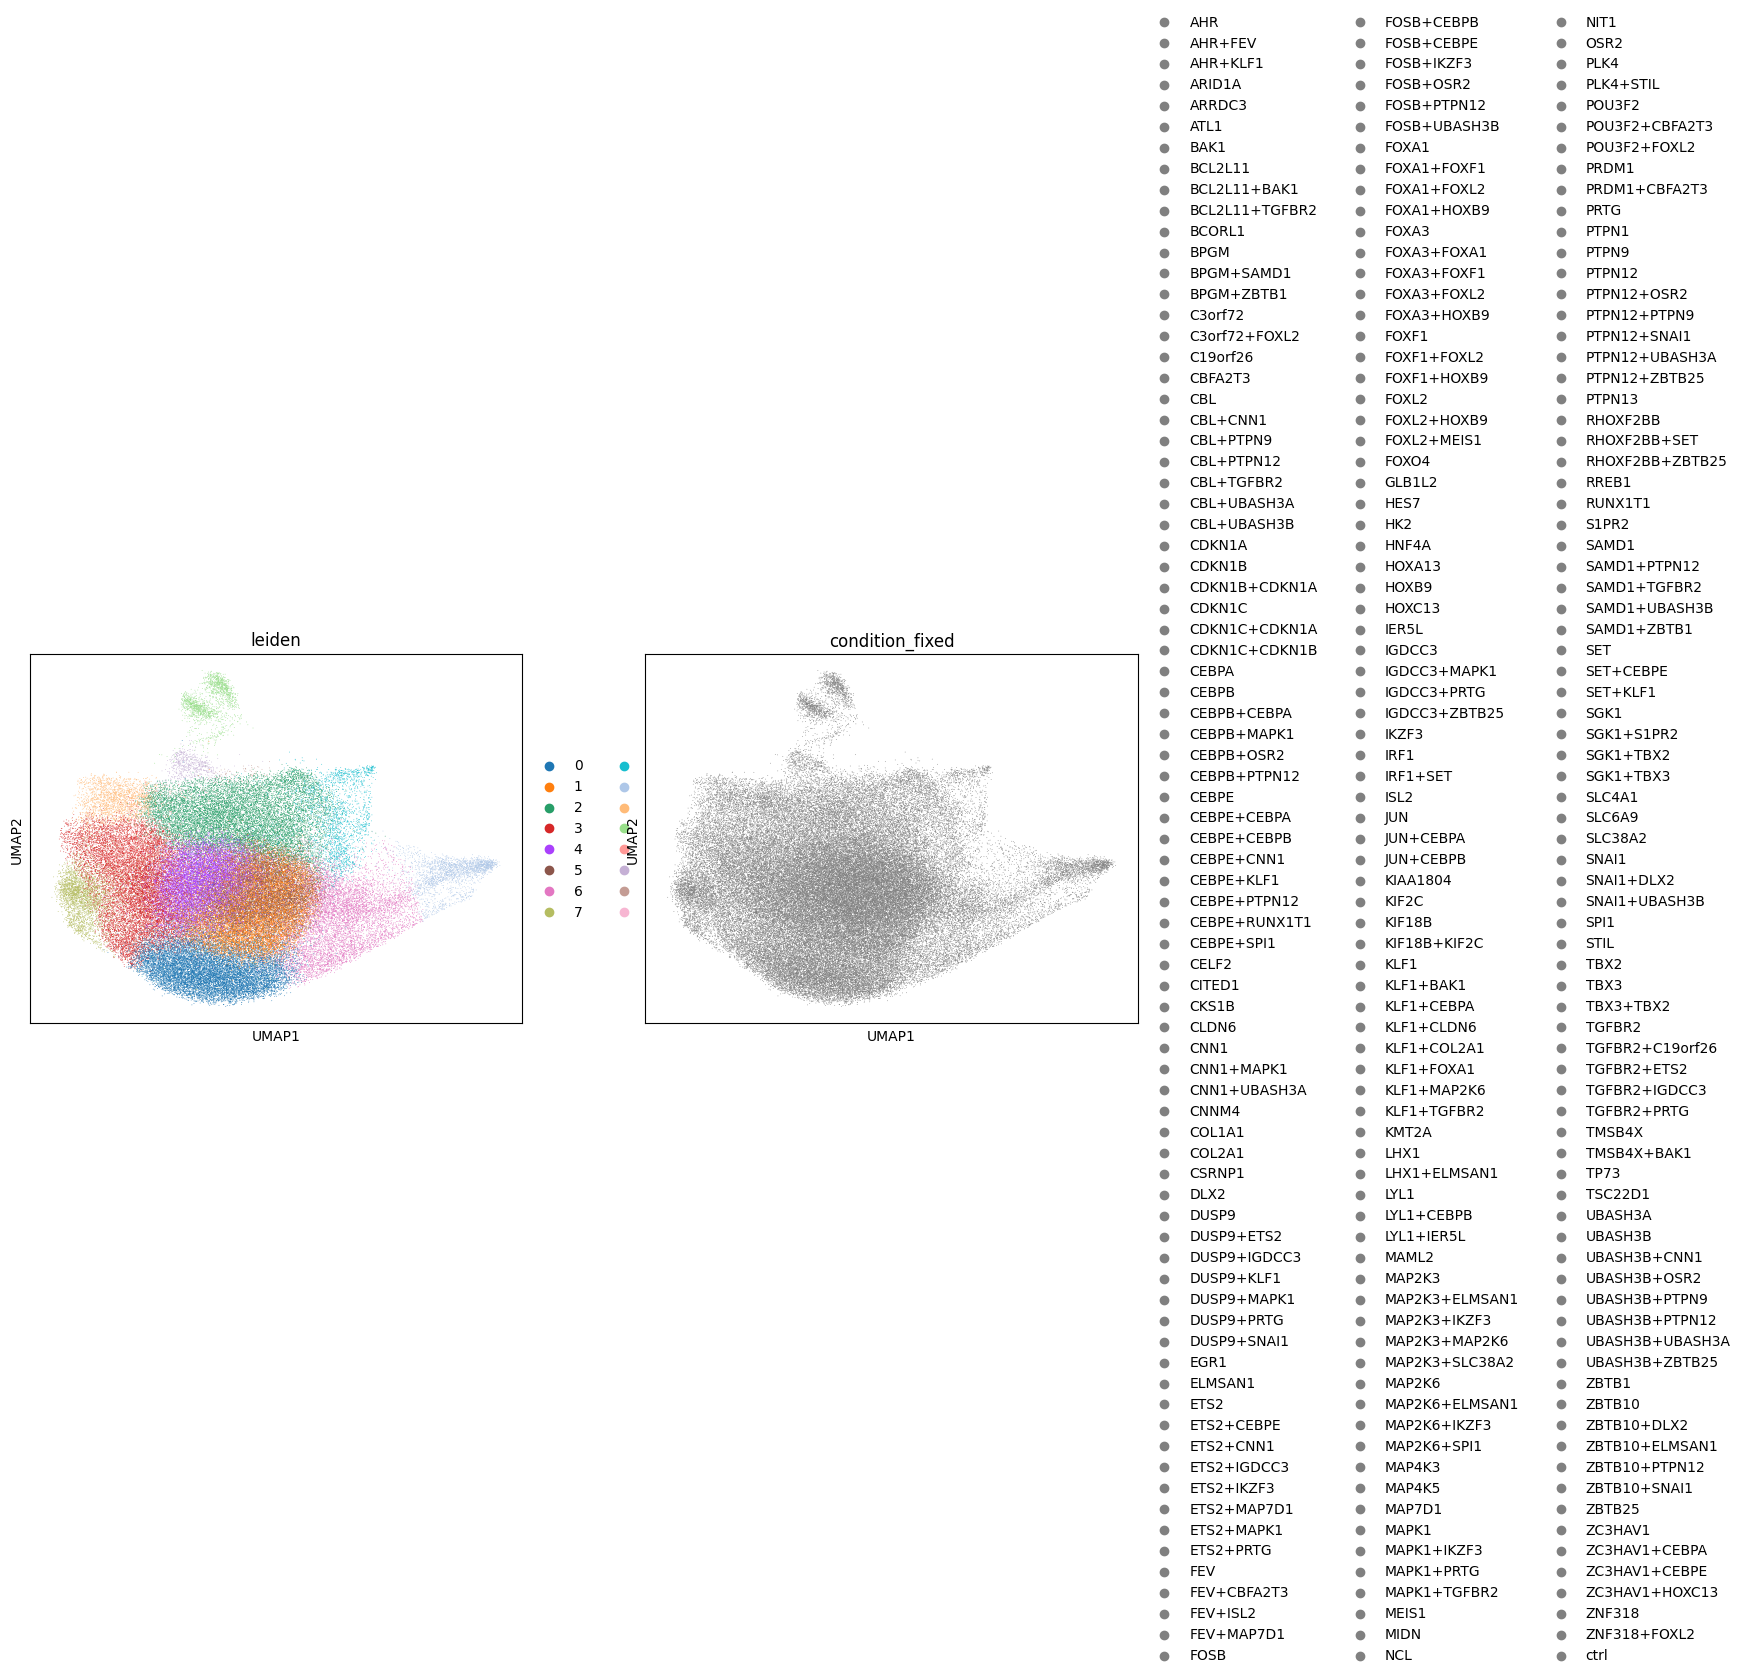

In [25]:
# PCA
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)
sc.pl.pca(adata, color='condition_fixed')

# Neighbors & Clustering
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata)

# UMAP (Faster and often preferred over t-SNE)
# sc.tl.umap(adata)
# sc.pl.umap(adata, color=['leiden', 'condition_fixed'])

# t-SNE (Often slower, uncomment if needed)
# try:
#     sc.tl.tsne(adata, n_jobs=-1)
#     sc.pl.tsne(adata, color=['leiden', 'condition_fixed'])
# except Exception as e:
#     print(f"Skipping t-SNE due to error: {e}")

### 3. Visualization
Visualize the cell embeddings labeled by Leiden algorithm clusters and experimental conditions.

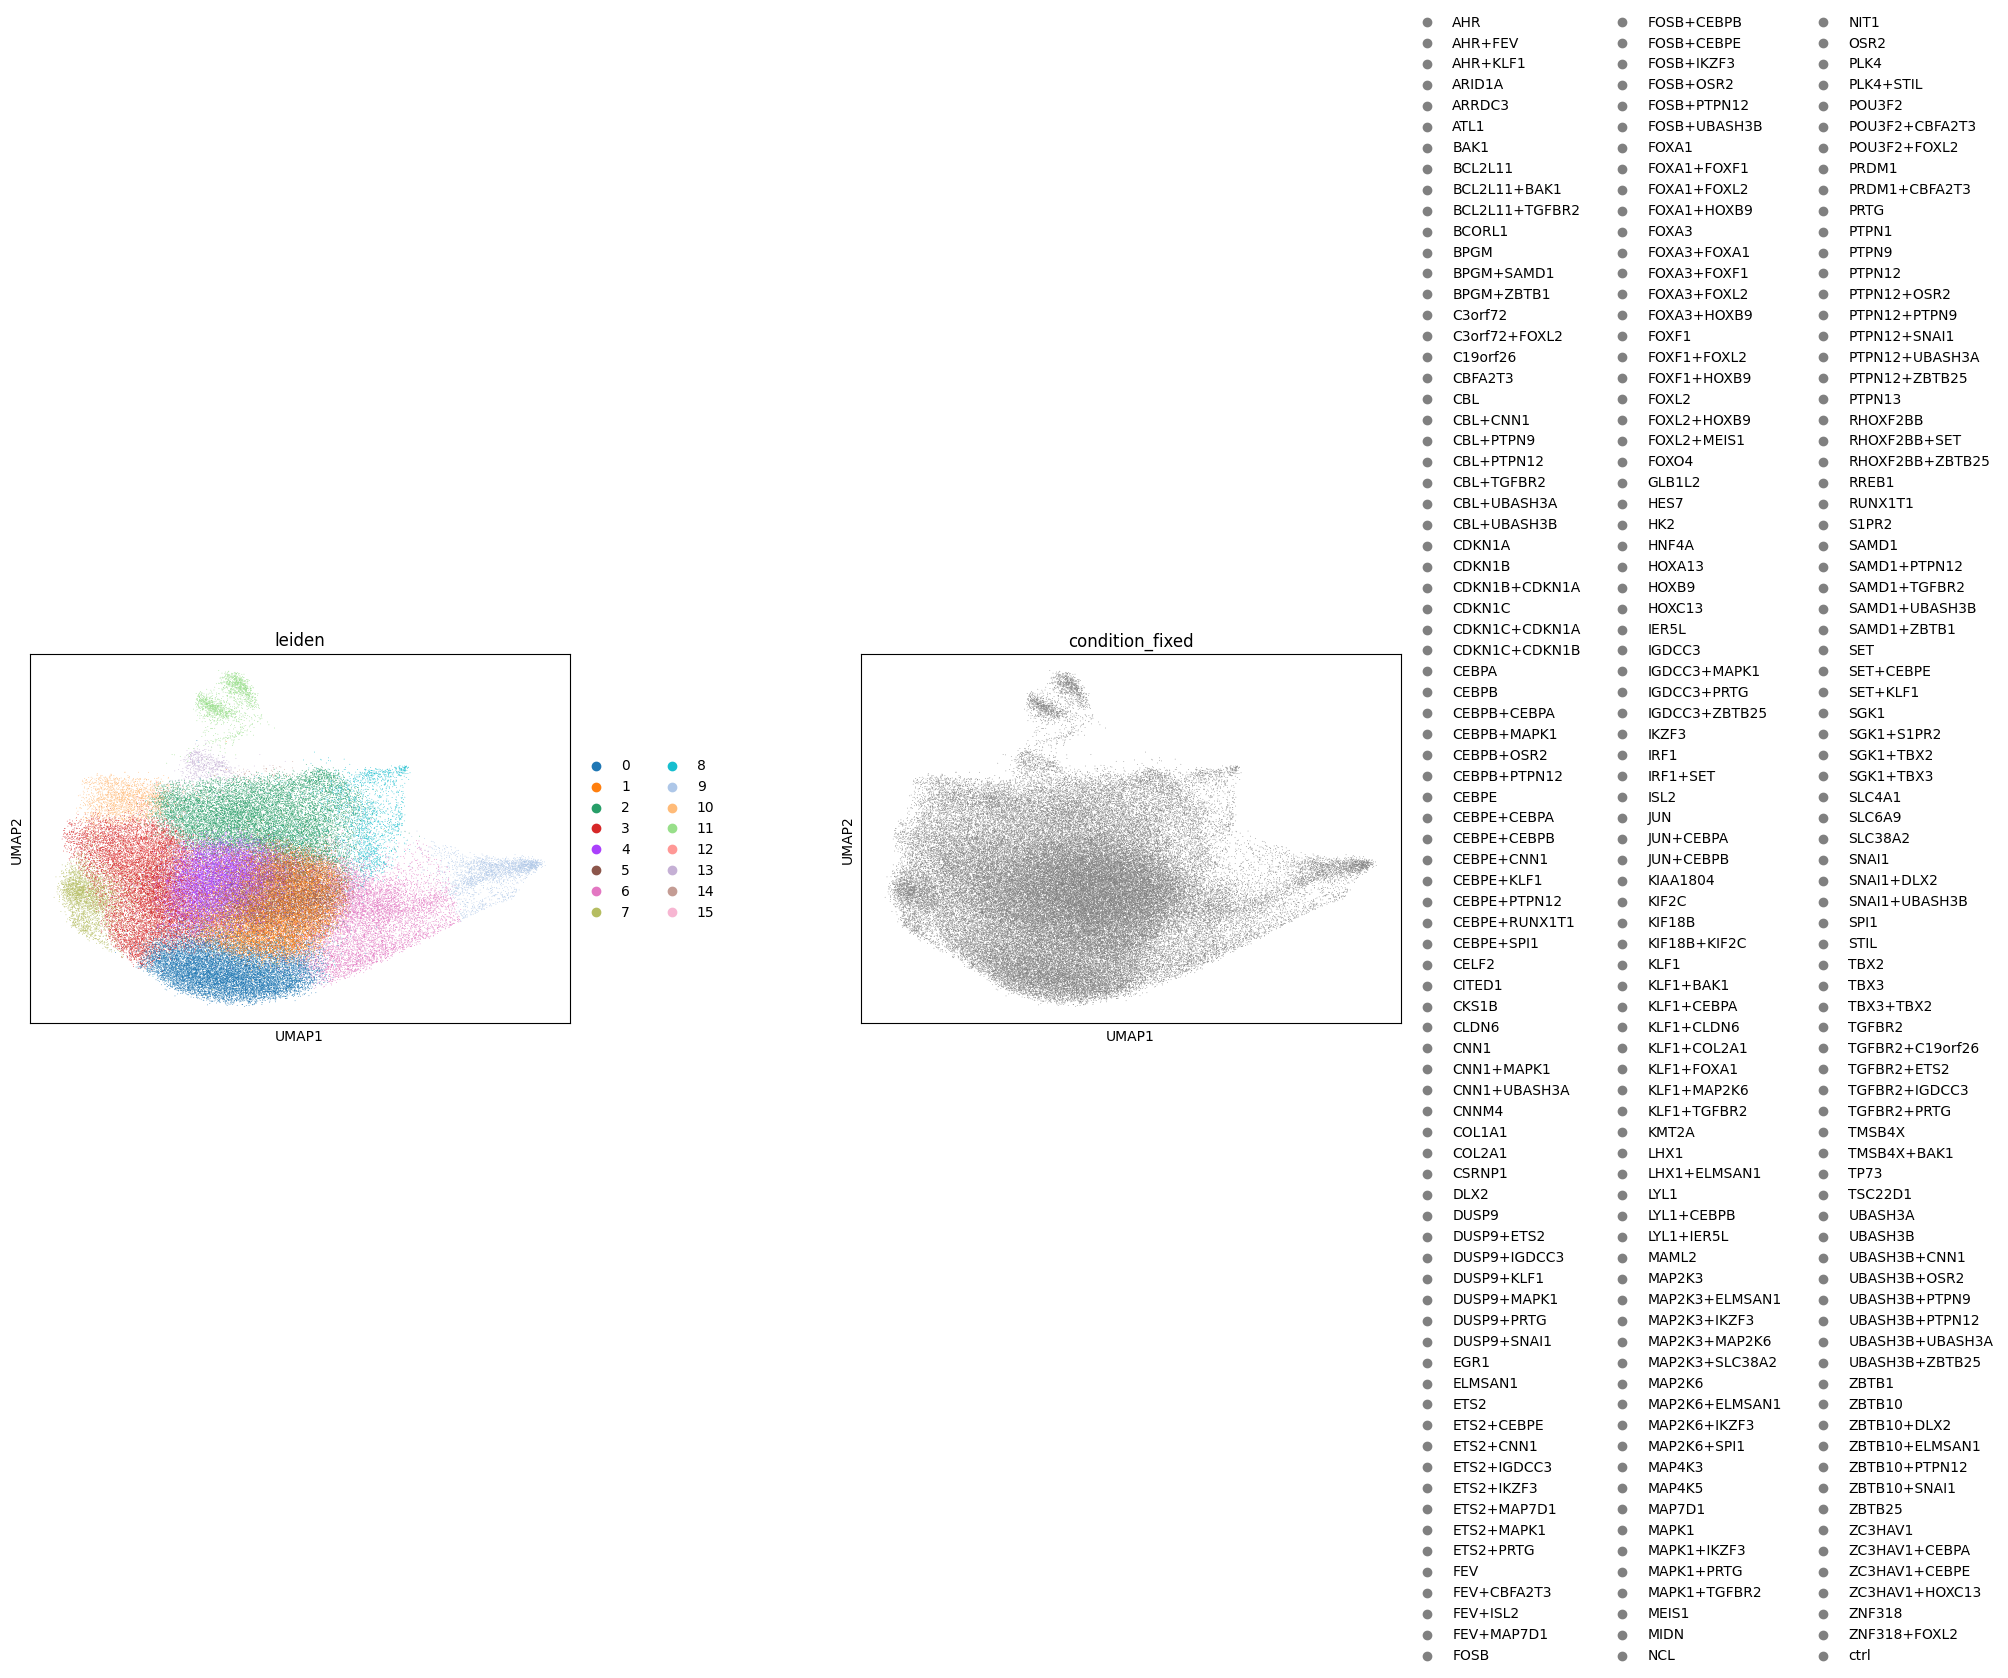

In [26]:
sc.pl.umap(adata, color=['leiden', 'condition_fixed'], wspace=0.4)

### 4. Perturbation × Cluster Composition
Analyze how different perturbations are distributed across the identified clusters.

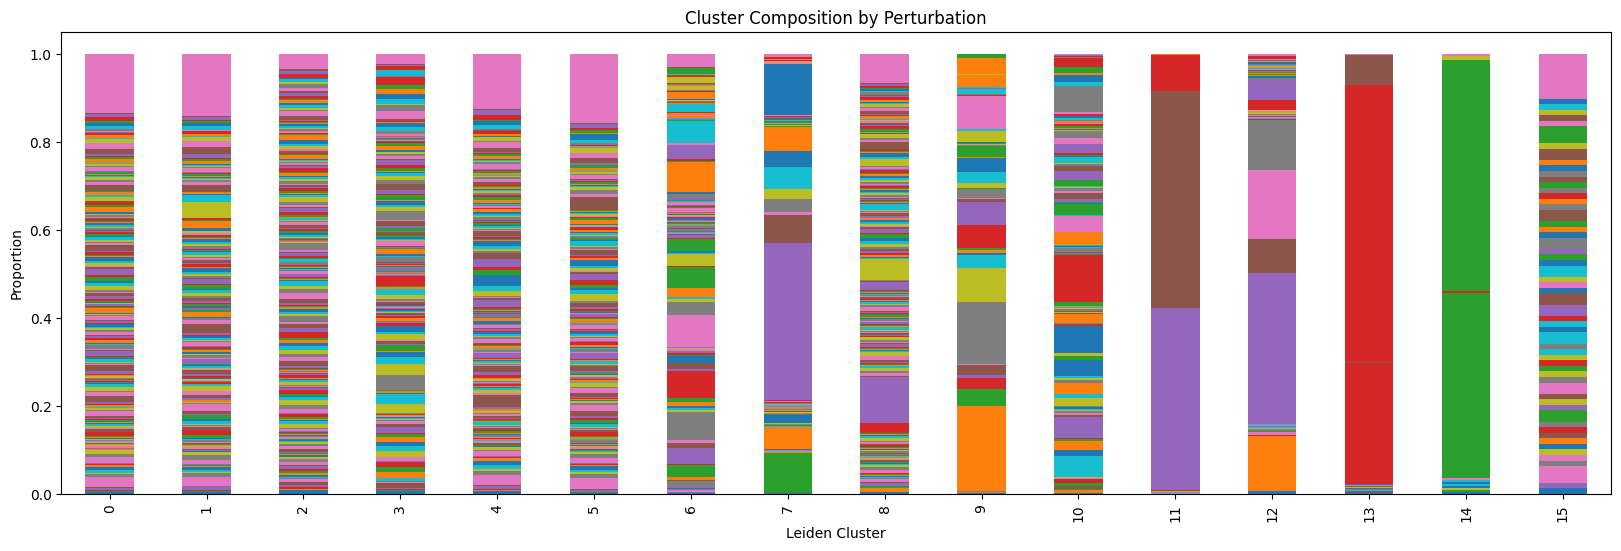

In [27]:
composition = pd.crosstab(adata.obs['leiden'], adata.obs['condition_fixed'], normalize='index')

# Plotting a subset or full heatmap/bar might be messy if there are many conditions.
# Here we plot the top contributing conditions for cleanliness or just a full bar chart.
ax = composition.plot(kind='bar', stacked=True, figsize=(20, 6), legend=False)
plt.title("Cluster Composition by Perturbation")
plt.xlabel("Leiden Cluster")
plt.ylabel("Proportion")
plt.show()

### 5. Cluster Markers
Identify genes that define each cluster.

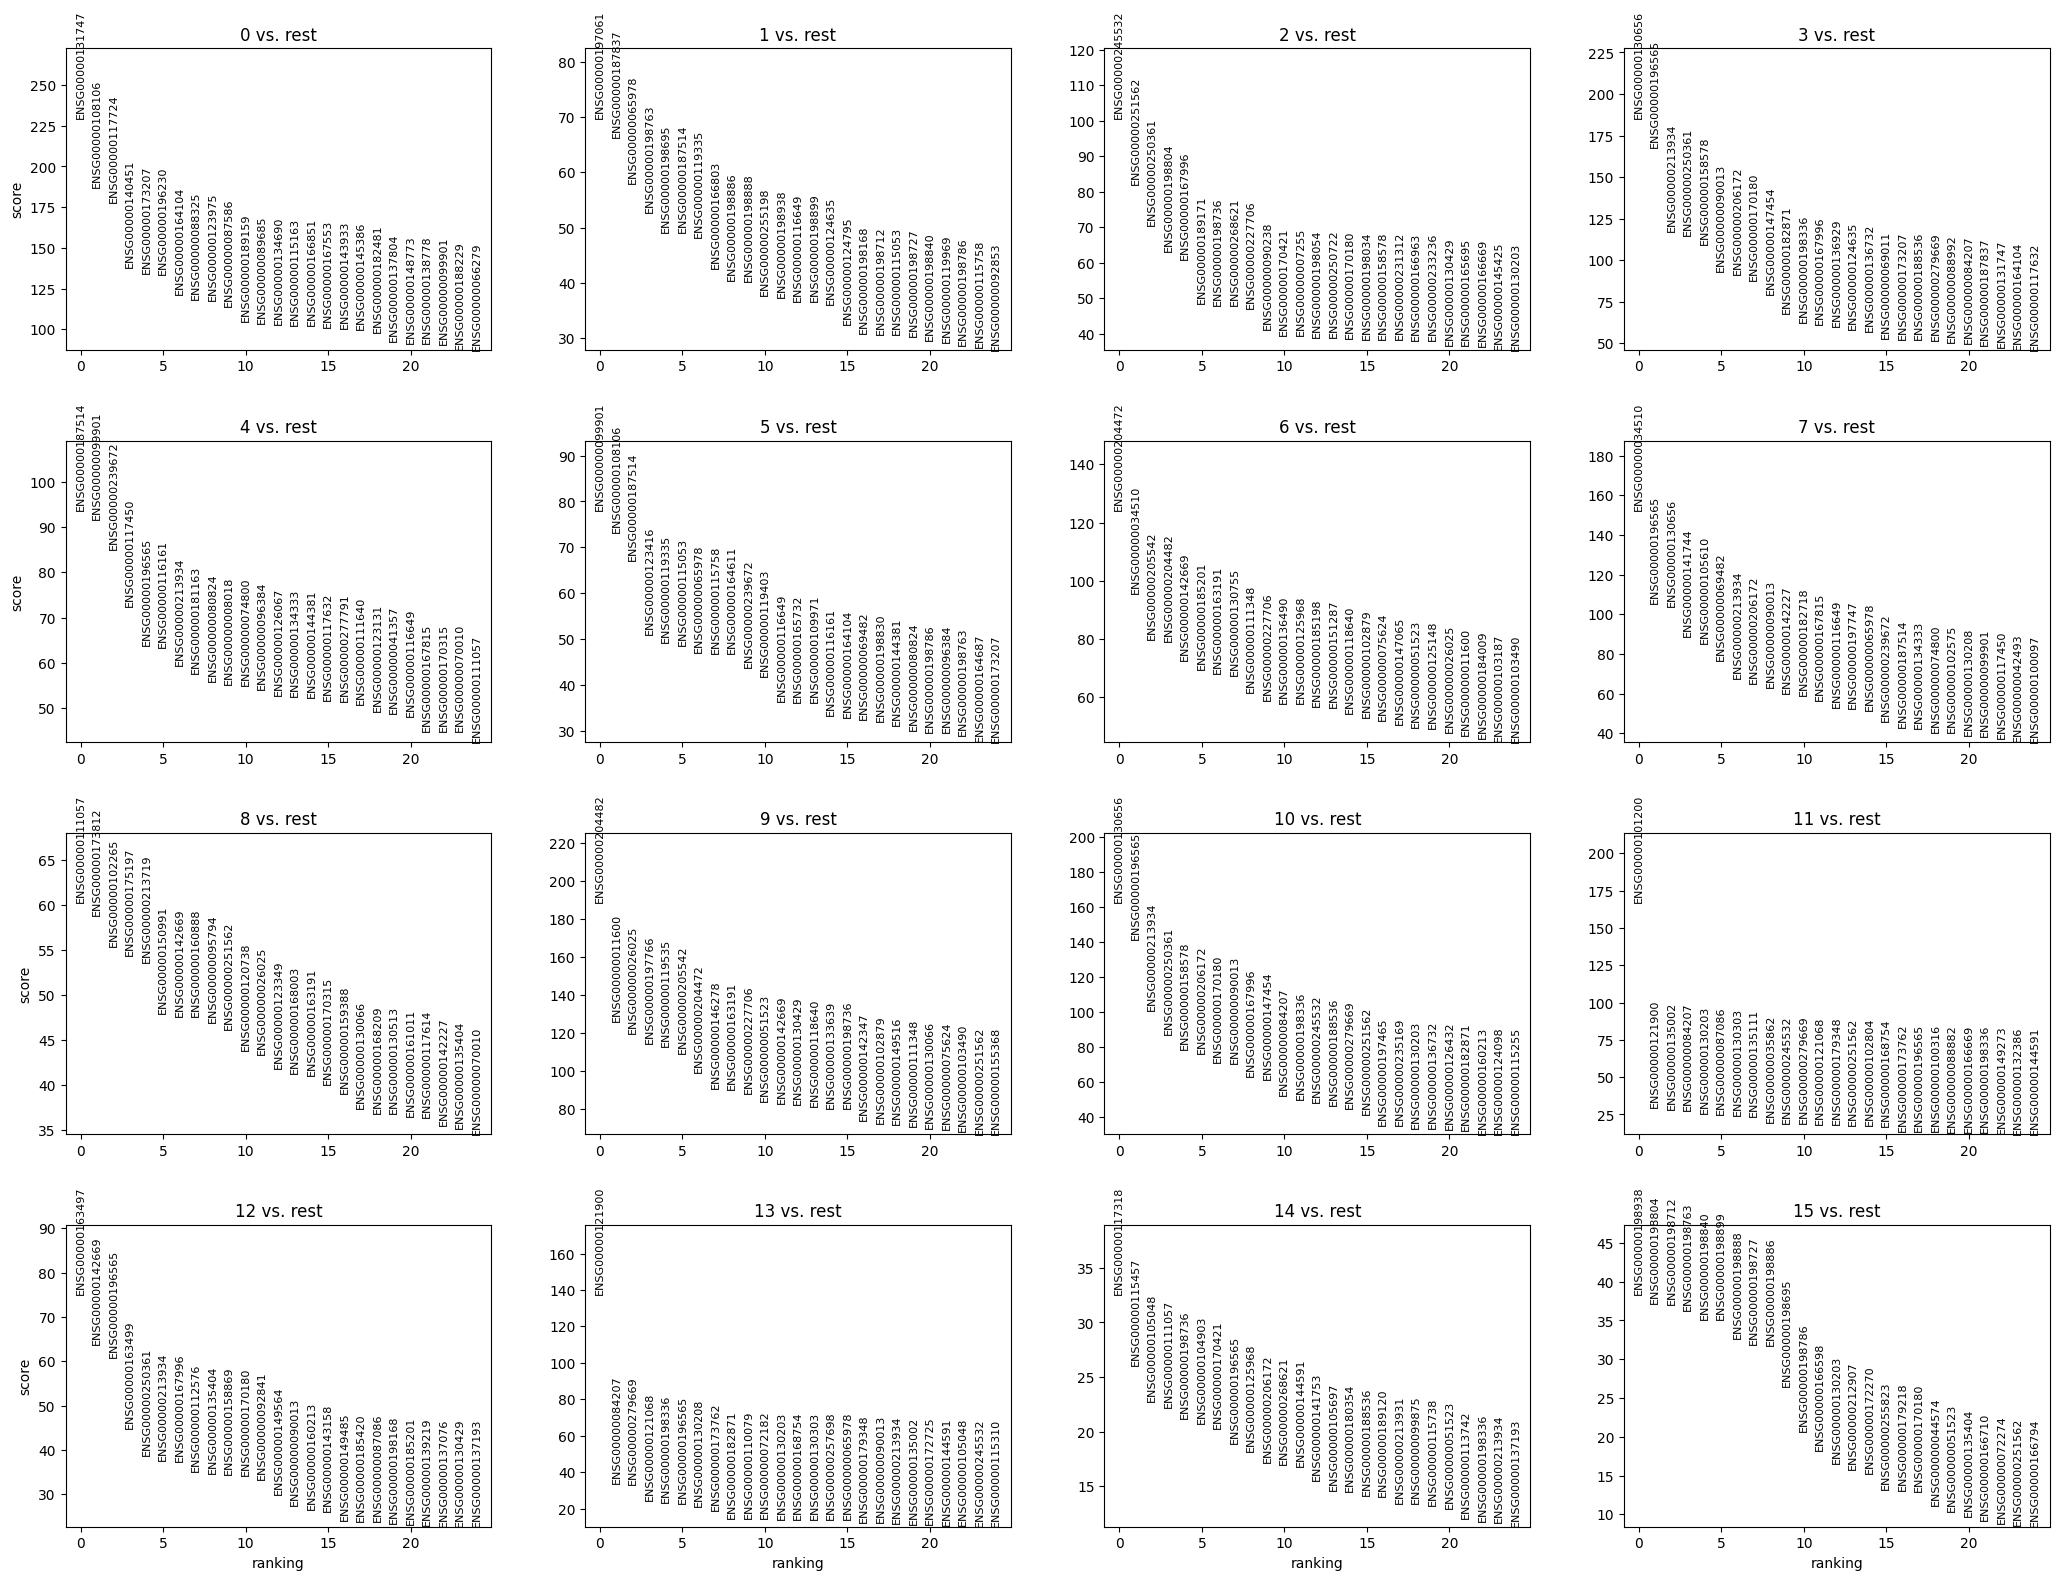

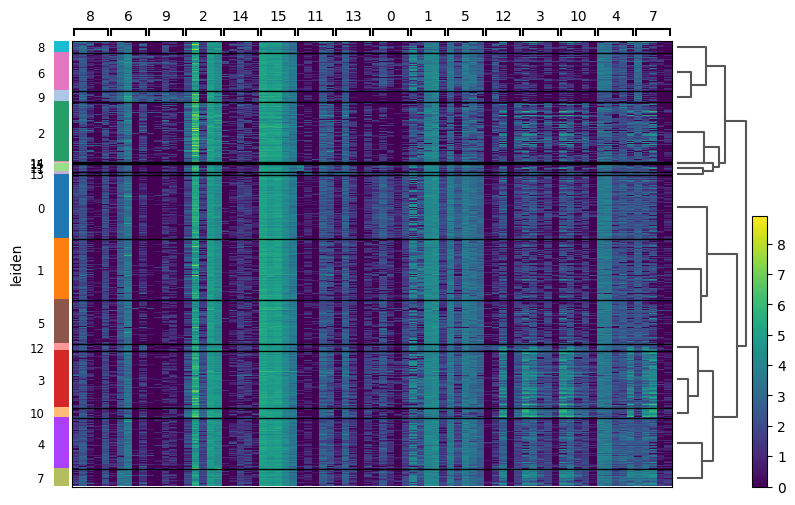

In [28]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, groupby='leiden')

### 6. Pathway / Gene Set Scoring
Score cells based on the expression of a set of genes (e.g., a pathway).

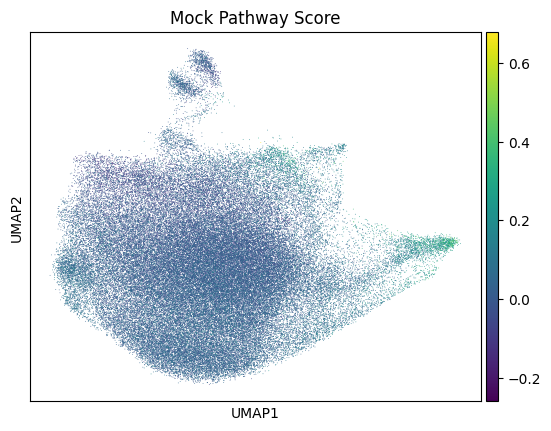

In [29]:
# Example: Scoring based on the top 50 highly variable genes as a 'Mock Pathway'
# In practice, replace 'gene_list' with your specific pathway genes (e.g., ['CDK1', 'CCNB1', ...])
gene_list = adata.var[adata.var['highly_variable']].index[:50].tolist()

sc.tl.score_genes(adata, gene_list, score_name='mock_pathway_score')
sc.pl.umap(adata, color='mock_pathway_score', title='Mock Pathway Score')